In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

### Uploading the dataset 

In [2]:
data = pd.read_csv("student_performance.csv")

### Data Understanding and Inspection

In [3]:
data.head()

,Student_ID,Name,Age,Study_Hours,Attendance,Previous_Marks,Assignments,Backlogs,Internet_Access,Pass
0,10001,Student_1,19.0,5.8,88.1,75.5,2.0,0,No,0
1,10002,Student_2,23.0,6.1,92.0,62.9,7.0,2,No,0
2,10003,Student_3,21.0,5.9,71.0,70.9,3.0,2,Yes,1
3,10004,Student_4,20.0,5.0,64.1,76.1,10.0,0,Yes,0
4,10005,Student_5,19.0,4.4,88.2,59.3,2.0,0,Yes,1


In [4]:
data.tail()

,Student_ID,Name,Age,Study_Hours,Attendance,Previous_Marks,Assignments,Backlogs,Internet_Access,Pass
2495,12496,Student_2496,20.0,2.1,99.7,68.8,9.0,0,Yes,0
2496,12497,Student_2497,20.0,1.7,100.0,83.7,2.0,0,No,0
2497,12498,Student_2498,22.0,6.1,79.2,65.0,7.0,0,Yes,1
2498,12499,Student_2499,24.0,7.2,91.4,73.7,8.0,1,Yes,1
2499,12500,Student_2500,20.0,8.5,80.8,67.4,3.0,0,Yes,1


In [5]:
data.shape

(2500, 10)

In [6]:
data.columns

Index(['Student_ID', 'Name', 'Age', 'Study_Hours', 'Attendance',
       'Previous_Marks', 'Assignments', 'Backlogs', 'Internet_Access', 'Pass'],
      dtype='object')

In [7]:
data.dtypes

Student_ID           int64
Name                object
Age                float64
Study_Hours        float64
Attendance         float64
Previous_Marks     float64
Assignments        float64
Backlogs             int64
Internet_Access     object
Pass                 int64
dtype: object

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Student_ID       2500 non-null   int64  
 1   Name             2500 non-null   object 
 2   Age              2494 non-null   float64
 3   Study_Hours      2498 non-null   float64
 4   Attendance       2497 non-null   float64
 5   Previous_Marks   2488 non-null   float64
 6   Assignments      2498 non-null   float64
 7   Backlogs         2500 non-null   int64  
 8   Internet_Access  2498 non-null   object 
 9   Pass             2500 non-null   int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 195.4+ KB


In [9]:
data.describe()

,Student_ID,Age,Study_Hours,Attendance,Previous_Marks,Assignments,Backlogs,Pass
count,2500.00000,2494.000000,2498.000000,2497.000000,2488.000000,2498.000000,2500.000000,2500.000000
mean,11250.50000,20.028067,4.766493,77.414337,68.123754,5.911529,0.618800,0.803200
std,721.83216,1.633489,2.017479,11.860344,15.005373,2.598592,0.963461,0.399667
min,10001.00000,12.000000,-2.000000,-5.000000,-10.000000,2.000000,0.000000,-1.000000
25%,10625.75000,19.000000,3.400000,69.400000,58.200000,4.000000,0.000000,1.000000
50%,11250.50000,20.000000,4.800000,77.500000,68.100000,6.000000,0.000000,1.000000
75%,11875.25000,21.000000,6.100000,86.000000,78.500000,8.000000,1.000000,1.000000
max,12500.00000,45.000000,25.000000,110.000000,105.000000,10.000000,4.000000,2.000000


In [10]:
pd.DataFrame(data['Name'].unique()) # nunique -> total number of unique values 

,0
0,Student_1
1,Student_2
2,Student_3
3,Student_4
4,Student_5
...,...
2495,Student_2496
2496,Student_2497
2497,Student_2498
2498,Student_2499


In [10]:
# Splitting the features into categorical and numerical features

categorical_features = data.select_dtypes(include=['object']).columns.tolist()
numerical_features = data.select_dtypes(include=[np.number]).columns.tolist()

In [11]:
len(categorical_features)

2

In [12]:
len(numerical_features)

8

# Exploratory Data Analysis

### Handling Missing and Filtering the Values

In [13]:
data.isnull().sum()

Student_ID          0
Name                0
Age                 6
Study_Hours         2
Attendance          3
Previous_Marks     12
Assignments         2
Backlogs            0
Internet_Access     2
Pass                0
dtype: int64

In [14]:
# Fill the NaN values of Previous_Marks with median value
data["Previous_Marks"] = data["Previous_Marks"].fillna(data["Previous_Marks"].median())

In [15]:
# Drop the NaN values because it contains only less number of NaN values
data.dropna(subset=['Age', 'Study_Hours', 'Attendance', 'Assignments', 'Internet_Access'],  inplace=True)

In [16]:
data.isnull().sum() # check the NaN values

Student_ID         0
Name               0
Age                0
Study_Hours        0
Attendance         0
Previous_Marks     0
Assignments        0
Backlogs           0
Internet_Access    0
Pass               0
dtype: int64

### Handling Duplicates

In [17]:
data.duplicated().sum()
# data.duplicated.any() --> check the duplicate records

np.int64(0)

### Handling outliers by filtering them 

In [18]:
# Unrealistic age (< 18 or > 100)
invalid_age_count = ((data['Age'] < 0) | (data['Age'] > 100)).sum()

print("\nInvalid Age count:", invalid_age_count)
# print("\nInvalid Age values:")

# Correct usage of .loc with square brackets
# display(data.loc[(data['Age'] < 0) | (data['Age'] > 100), ['Student_ID', 'Age']])



Invalid Age count: 0


In [19]:
invalid_attendance = ((data['Attendance'] < 0) | (data['Attendance'] > 100)).sum()
print("Invalid_attendance:", invalid_attendance)
display(data.loc[(data['Attendance'] < 0) | (data['Attendance'] > 100), ['Student_ID', 'Attendance']])

# Drop rows with invalid attendance values by filtering
data = data[(data['Attendance'] >= 0) & (data['Attendance'] <= 100)]


Invalid_attendance: 2


,Student_ID,Attendance
70,10071,110.0
71,10072,-5.0


In [ ]:
data[data['Student_ID'] == 10071] # check it has removed

,Student_ID,Name,Age,Study_Hours,Attendance,Previous_Marks,Assignments,Backlogs,Internet_Access,Pass


In [21]:
# Checking the invalid values for Previous_marks
# Unrealist marks 
invalid_previous_marks = ((data['Previous_Marks'] < 0) | (data['Previous_Marks']) > 100).sum()
print(invalid_previous_marks)

0


In [22]:
invalid_pass_count = ((data['Pass'] != 0) & (data['Pass'] != 1)).sum()
print("Invalid Pass count:", invalid_pass_count)

display(data.loc[(data['Pass'] != 0) & (data['Pass'] != 1), ['Student_ID', 'Pass']])

# handling the pass values by filtering it
data = data[(data['Pass'] == 1) | (data['Pass'] == 0) ]



Invalid Pass count: 2


,Student_ID,Pass
130,10131,2
131,10132,-1


In [23]:
data.head()

,Student_ID,Name,Age,Study_Hours,Attendance,Previous_Marks,Assignments,Backlogs,Internet_Access,Pass
0,10001,Student_1,19.0,5.8,88.1,75.5,2.0,0,No,0
1,10002,Student_2,23.0,6.1,92.0,62.9,7.0,2,No,0
2,10003,Student_3,21.0,5.9,71.0,70.9,3.0,2,Yes,1
3,10004,Student_4,20.0,5.0,64.1,76.1,10.0,0,Yes,0
4,10005,Student_5,19.0,4.4,88.2,59.3,2.0,0,Yes,1


In [24]:
data.shape

(2481, 10)

In [25]:
# outlier handling

Q1 = data['Age'].quantile(0.25)
Q3 = data['Age'].quantile(0.75)
IQR = Q3 - Q1

# Define outliers
# outliers = data[(data['Age'] < (Q1 - 1.5 * IQR)) | (data['Age'] > (Q3 + 1.5 * IQR))]
# print("Outliers:\n", outliers)

# Remove outliers
# data_no_outliers = data[~data.index.isin(outliers.index)]
# print("Dataset without outliers:\n", data_no_outliers)

# Logical checks
unusual = data[(data['Age'] < 0) | (data['Age'] > 120)]
print("Unusual values:\n", unusual)


Unusual values:
 Empty DataFrame
Columns: [Student_ID, Name, Age, Study_Hours, Attendance, Previous_Marks, Assignments, Backlogs, Internet_Access, Pass]
Index: []


### Downloading the cleaned data

In [27]:
# download the cleaned dataset for PowerBI Visualization

cleaned_data = data
cleaned_data.to_csv("cleaned_student_performance_data.csv", index=False)

In [28]:
cleaned_data.head()

,Student_ID,Name,Age,Study_Hours,Attendance,Previous_Marks,Assignments,Backlogs,Internet_Access,Pass
0,10001,Student_1,19.0,5.8,88.1,75.5,2.0,0,No,0
1,10002,Student_2,23.0,6.1,92.0,62.9,7.0,2,No,0
2,10003,Student_3,21.0,5.9,71.0,70.9,3.0,2,Yes,1
3,10004,Student_4,20.0,5.0,64.1,76.1,10.0,0,Yes,0
4,10005,Student_5,19.0,4.4,88.2,59.3,2.0,0,Yes,1


In [29]:
cleaned_data.shape

(2481, 10)

## Visualization

C:\Users\Inzeera Zakariah\AppData\Local\Temp\ipykernel_21280\1359523322.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=cleaned_data["Pass"], palette="Set1")


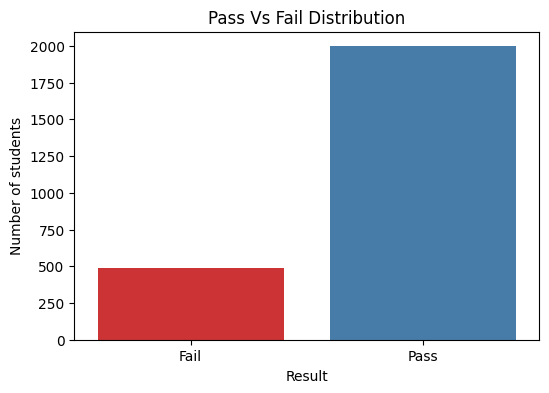

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x=cleaned_data["Pass"], palette="Set1")
plt.title("Pass Vs Fail Distribution")
plt.xlabel("Result")
plt.ylabel("Number of students")
plt.xticks([0,1], ["Fail", "Pass"])
plt.show()

     Student_ID         Name   Age  Study_Hours  Attendance  Previous_Marks  \
110       10111  Student_111  19.0         25.0        87.7            47.4   
111       10112  Student_112  19.0         -2.0        71.0            85.7   

     Assignments  Backlogs Internet_Access  Pass  
110          9.0         0             Yes     1  
111          3.0         0             Yes     0  


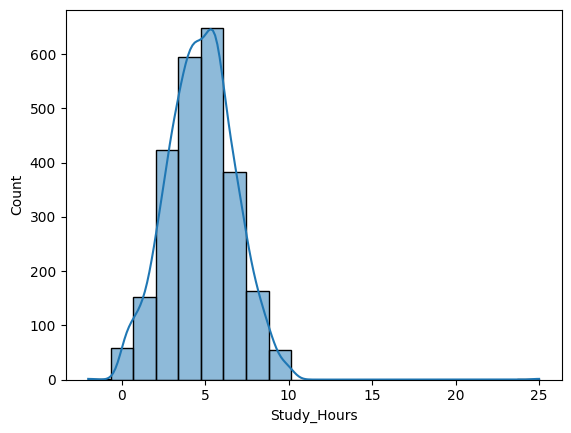

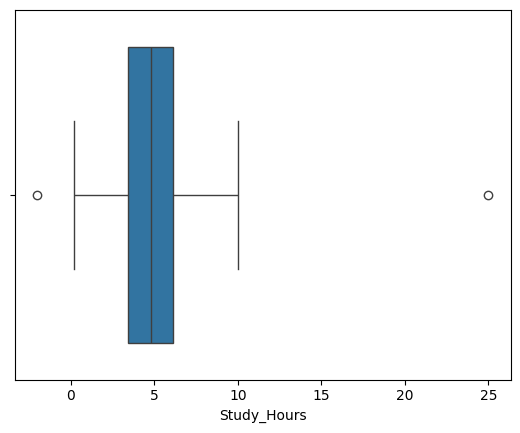

In [37]:
Q1 = cleaned_data['Study_Hours'].quantile(0.25)
Q3 = cleaned_data['Study_Hours'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = cleaned_data[(cleaned_data['Study_Hours'] < lower_bound) | (cleaned_data['Study_Hours'] > upper_bound)]
print(outliers)

sns.histplot(cleaned_data['Study_Hours'], bins=20, kde=True)
plt.show()

sns.boxplot(x=cleaned_data['Study_Hours'])
plt.show()



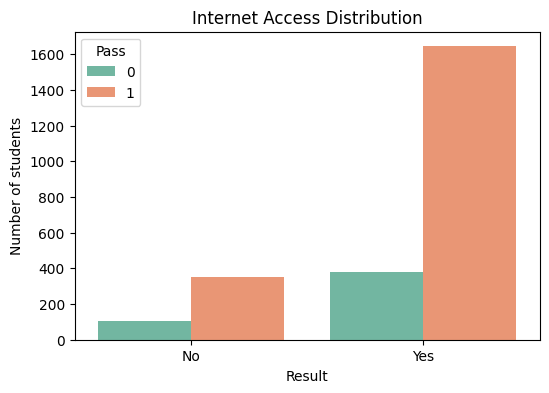

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x=cleaned_data["Internet_Access"],hue=cleaned_data['Pass'], palette="Set2")
plt.title("Internet Access Distribution")
plt.xlabel("Result")
plt.ylabel("Number of students")
plt.show()

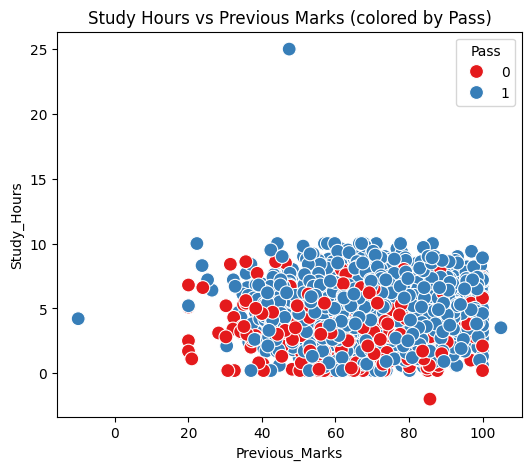

In [32]:
plt.figure(figsize=(6,5))
sns.scatterplot(x="Previous_Marks", y="Study_Hours", hue="Pass", data=cleaned_data,palette="Set1", s=100)
plt.title("Study Hours vs Previous Marks (colored by Pass)")
plt.show()

C:\Users\Inzeera Zakariah\AppData\Local\Temp\ipykernel_21280\1950279488.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pass", y="Study_Hours", data=cleaned_data, palette="Set2")


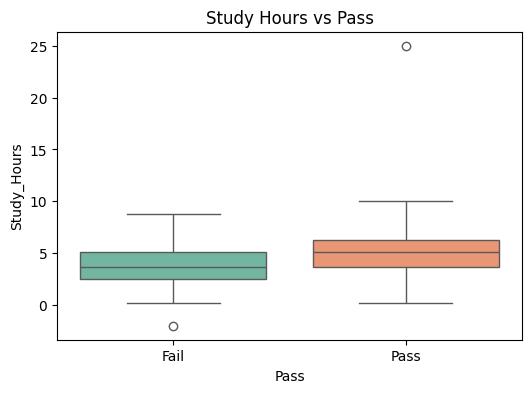

In [33]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Pass", y="Study_Hours", data=cleaned_data, palette="Set2")
plt.xticks([0,1], ["Fail", "Pass"])
plt.title("Study Hours vs Pass")
plt.show()

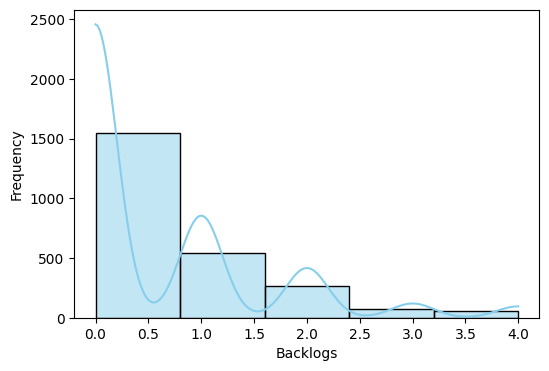

In [34]:
plt.figure(figsize=(6,4))
sns.histplot(cleaned_data['Backlogs'],kde=True, bins=5, color='skyblue')
plt.ylabel("Frequency")
plt.show()

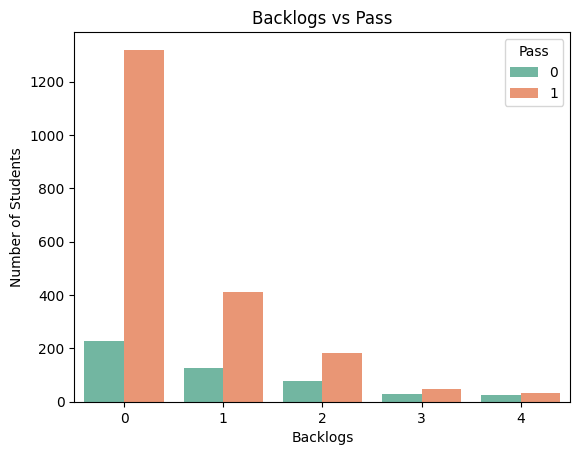

In [38]:
sns.countplot(x="Backlogs", hue="Pass", data=cleaned_data, palette="Set2")
plt.title("Backlogs vs Pass")
plt.ylabel("Number of Students")
plt.show()

C:\Users\Inzeera Zakariah\AppData\Local\Temp\ipykernel_21280\3427941283.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Internet_Access", y="Study_Hours", data=cleaned_data, palette="Set1")


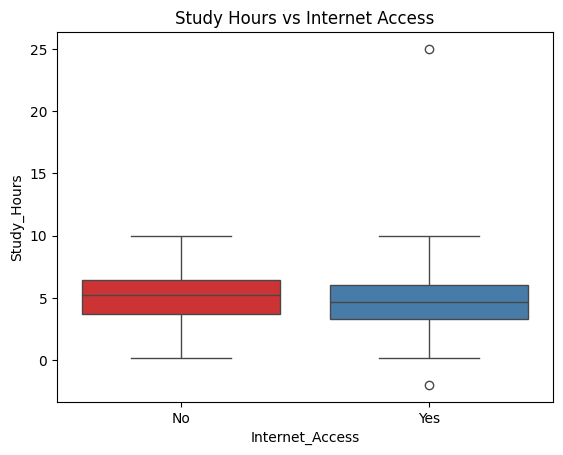

Internet_Access
No     5.02193
Yes    4.71200
Name: Study_Hours, dtype: float64

In [39]:
sns.boxplot(x="Internet_Access", y="Study_Hours", data=cleaned_data, palette="Set1")
plt.title("Study Hours vs Internet Access")
plt.show()

# Grouped mean comparison
cleaned_data.groupby("Internet_Access")["Study_Hours"].mean()


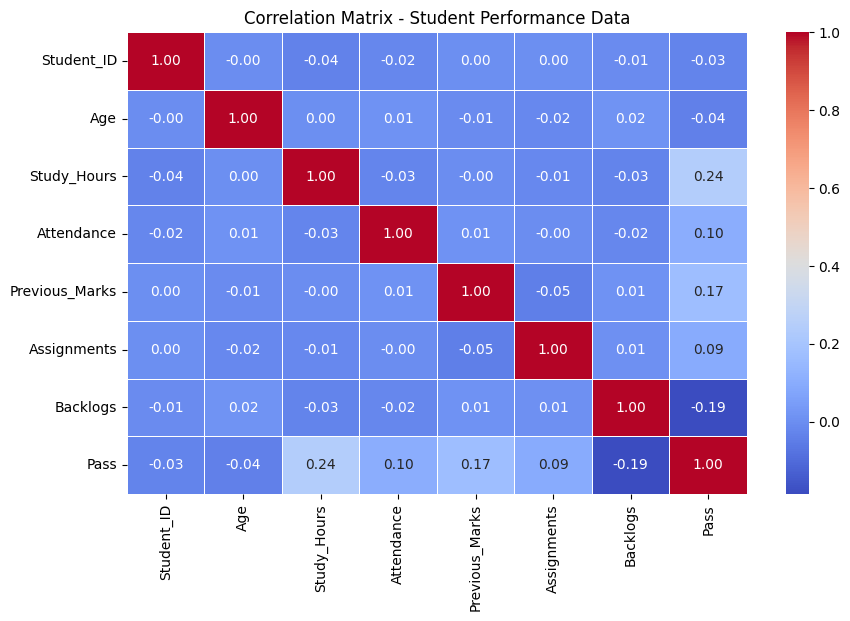

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(cleaned_data[numerical_features].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix - Student Performance Data")
plt.show()